## 2. EDA

In [1]:
# Install Transformers and Datasets
!pip install transformers datasets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.4 MB/s eta 0:00:00


In [2]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
!pip install py7zr --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 28.5 MB/s eta 0:00:00


In [4]:
from datasets import load_dataset

dataset = load_dataset("samsum")
dataset

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


samsum.py:   0%|          | 0.00/3.36k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/7.04k [00:00<?, ?B/s]

The repository for samsum contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/samsum.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


corpus.7z:   0%|          | 0.00/2.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14732 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14732
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
})

In [5]:
dataset["train"][12032]

{'id': '13611481',
 'dialogue': "Kelly: Hey, what are you doing tonight?\r\nClaudia: Nothing much\r\nKelly: Are you studying all day?\r\nClaudia: Pretty much :-/\r\nKelly: Wanna go to the movies?\r\nClaudia: Hmm...maybe. Anything interesting out there?\r\nKelly: I feel like a dumb comedy. That new Johnny English movie is out. Wanna go see it?\r\nClaudia: Sure, I've been cooped up in here for too long. I haven't seen the previous ones though.\r\nKelly: You don't need to, each one can stand on it's own.\r\nClaudia: Ok, so where do you want to meet?\r\nKelly: Let's meet at Cloverdale mall at 5, then we'll check what time it's playing and eat something\r\nClaudia: Ok, are you driving?\r\nKelly: No, I'll probably take the bus\r\nClaudia: Ok, see ya\r\nKelly: see ya ",
 'summary': 'Kelly and Claudia are going to watch Johnny English. Kelly will meet Claudia at Cloverdale Mall at 5 so they can eat something first. Claudia is taking the bus. '}

In [6]:
conv_len = []
num_messages = []
summary_len = []
for conv in dataset["train"]:
  dialogue = conv["dialogue"]
  summary_len.append(len(conv["summary"]))
  conv_len.append(len(dialogue))
  num_messages.append(len(dialogue.split("\n")))

In [7]:
import numpy as np

conv_len = np.array(conv_len)
summary_len = np.array(summary_len)
num_messages = np.array(num_messages)

print("Average conversation length:", conv_len.mean())
print("Std conversation length:", conv_len.std())
print("Average summary length:", summary_len.mean())
print("Std summary length:", summary_len.std())
print("Average back and forth length:", num_messages.mean())
print("Std back and forth length:", num_messages.std())


Average conversation length: 511.18361390171054
Std conversation length: 402.6077709923135
Average summary length: 110.13467282106978
Std summary length: 60.8904046622258
Average back and forth length: 11.166711919630735
Std back and forth length: 6.4528856807506685


------------(2b)------------

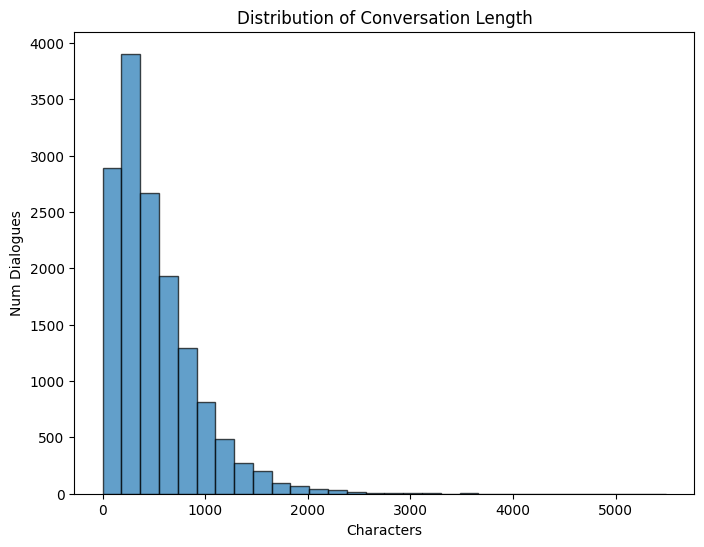

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(conv_len, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Conversation Length")
plt.xlabel("Characters")
plt.ylabel("Num Dialogues")
plt.show()

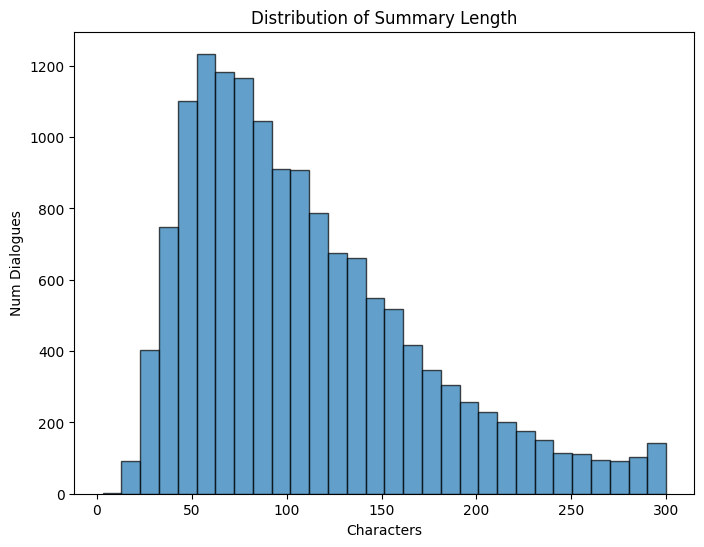

In [9]:
plt.figure(figsize=(8, 6))
plt.hist(summary_len, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Summary Length")
plt.xlabel("Characters")
plt.ylabel("Num Dialogues")
plt.show()

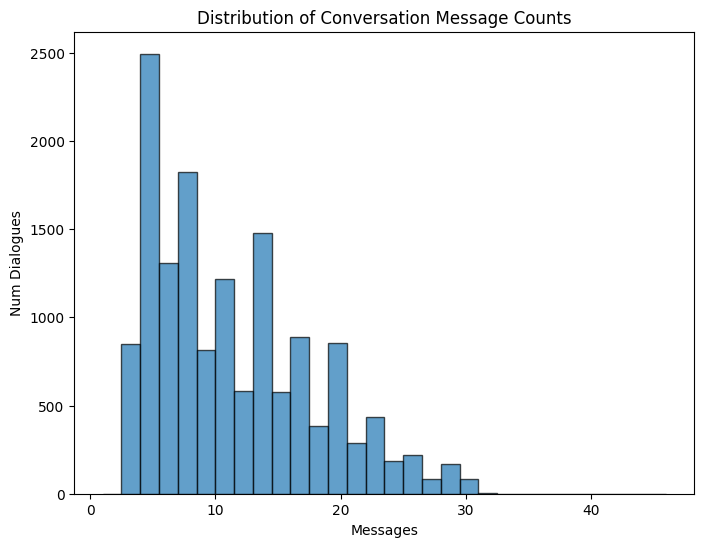

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(num_messages, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of Conversation Message Counts")
plt.xlabel("Messages")
plt.ylabel("Num Dialogues")
plt.show()

------------(2c)------------

In [11]:
from collections import Counter

word_counts = Counter()
for conv in dataset["train"]:
  dialogue = conv["dialogue"]
  words = dialogue.split()
  word_counts.update(words)
word_counts.most_common(20)


[('I', 37592),
 ('you', 31617),
 ('the', 29897),
 ('to', 28658),
 ('a', 21640),
 ('and', 15311),
 ('it', 14302),
 ('for', 11546),
 ('in', 10723),
 ('of', 10267),
 ('is', 10018),
 ('have', 9612),
 ('be', 8880),
 ('that', 8620),
 ('me', 7769),
 ('but', 7754),
 ('so', 7598),
 ('my', 7348),
 ('are', 7128),
 ("I'm", 7066)]

In [12]:
!pip install NLTK --quiet

In [13]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
word_counts_wout_stopwords = Counter()
for conv in dataset["train"]:
  dialogue = conv["dialogue"]
  words = dialogue.split()
  words = [word.lower() for word in words if word.lower() not in stopwords]
  word_counts_wout_stopwords.update(words)
word_counts_wout_stopwords.most_common(20)

[("i'm", 7960),
 ('like', 5463),
 ('know', 5430),
 ("i'll", 4289),
 (':)', 4041),
 ('think', 4032),
 ('see', 3807),
 ('get', 3690),
 ('good', 3614),
 ('go', 3398),
 ('one', 3052),
 ('need', 3030),
 ('time', 3027),
 ('would', 2968),
 ("that's", 2924),
 ('really', 2908),
 ('going', 2773),
 ('want', 2697),
 (':d', 2673),
 ('ok', 2540)]

## 3. Inference with Pre-Trained Models

------------(3a)------------

In [17]:
from transformers import pipeline

facebook_summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
google_summarizer = pipeline("summarization", model="google/pegasus-xsum")
distilbart_summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


------------(3b)------------

In [18]:
idxs = [15, 104, 298]
for i in idxs:
  dialogue = dataset["test"][i]["dialogue"]
  fb_summary = facebook_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)
  google_summary = google_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)
  distilbart_summary = distilbart_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)
  print("---------------------")
  print(f"Dialogue: {dialogue}")
  print(f"FB Summary: {fb_summary}")
  print(f"Google Summary: {google_summary}")
  print(f"Distilbart Summary: {distilbart_summary}")

---------------------
Dialogue: Greg: Hi, honey. I need to stay after hours :-(
Betsy: Again?
Greg: I'm sorry!
Betsy: What about Johnny?
Greg: Well, could you pick him up? 
Betsy: What if I can't?
Greg: Betsy?
Betsy: What if I can't?
Greg: Can't you, really?
Betsy: I can't. Today I need to work long hours as well. Tuesdays are your days in the kindergarten.
Greg: Talk to you later. I'll see what I can do.
Betsy: You'd better think of something.
Greg: Oh. Just stop it now.
FB Summary: [{'summary_text': "Greg: Hi, honey. I need to stay after hours. Betsy: What about Johnny? Greg: Well, could you pick him up? Betsy: I can't. Greg: Can't you,"}]
Google Summary: [{'summary_text': "Betsy: Hello, my name's Betsy and I'm the new teacher at your school."}]
Distilbart Summary: [{'summary_text': " Greg: Hi, honey. I need to stay after hours :-(\xa0\xa0\xa0\xa0\xa0Betsy: What if I can't?\xa0\xa0\xa0\xa0 Greg: Could you pick him up? \xa0\xa0\xa0\xa0\xa0\xa0 \xa0\xa0"}]
---------------------
Dialogu

The models do a decent job of finding the essential points of the dialogue. The Facebook model with BART large seems to do the best job with the selected dialogues. Google's Pegasus sees to do a good job at generating coherent language in the format of a summary, however the information in the summary seems to be less accurate. All of the models at some times seem to just pick out parts of the dialogues that seem important and directly print those parts as the summary, maybe with a few edits. Generally, summaries seem like they should be more along the lines of the Google model where it writes new sentences, however if this is at the cost of getting the information incorrect then the picking and highlighting method is also a good option.

## 4. Define a Baseline

------------(4a)------------

In [19]:
!pip install evaluate rouge_score

In [20]:
from nltk.tokenize import sent_tokenize
import evaluate
from rouge_score import rouge_scorer

def lead_3_basline(dialogue):
  sentences = sent_tokenize(dialogue)
  return " ".join(sentences[:3])

------------(4b)------------

In [21]:
dataset["test"][0]["summary"]

"Hannah needs Betty's number but Amanda doesn't have it. She needs to contact Larry."

In [22]:
nltk.download('punkt')

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

for i in idxs:
  dialogue = dataset["test"][i]["dialogue"]
  true_summary = dataset["test"][i]["summary"]
  fb_summary = str(facebook_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)[0]["summary_text"])
  google_summary = str(google_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)[0]["summary_text"])
  distilbart_summary = str(distilbart_summarizer(dialogue, max_length=45, min_length=20, do_sample=False)[0]["summary_text"])
  lead_3 = lead_3_basline(dialogue)
  fb_score = scorer.score(fb_summary, true_summary)
  google_score = scorer.score(google_summary, true_summary)
  distilbart_score = scorer.score(distilbart_summary, true_summary)
  lead_3_score = scorer.score(lead_3, true_summary)
  print("---------------------")
  print(f"Dialogue: {dialogue}")
  print(f"True Summary: {true_summary}")
  print(f"FB Score: {fb_score}")
  print(f"Google Score: {google_score}")
  print(f"Distilbart Score: {distilbart_score}")
  print(f"Lead 3 Score: {lead_3_score}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


---------------------
Dialogue: Greg: Hi, honey. I need to stay after hours :-(
Betsy: Again?
Greg: I'm sorry!
Betsy: What about Johnny?
Greg: Well, could you pick him up? 
Betsy: What if I can't?
Greg: Betsy?
Betsy: What if I can't?
Greg: Can't you, really?
Betsy: I can't. Today I need to work long hours as well. Tuesdays are your days in the kindergarten.
Greg: Talk to you later. I'll see what I can do.
Betsy: You'd better think of something.
Greg: Oh. Just stop it now.
True Summary: Greg and Betsy have a lot of work today, so they cannot pick up Johnny from the kindergarten. However, it's Greg's turn to do it. Greg will try to find a solution.
FB Score: {'rouge1': Score(precision=0.23529411764705882, recall=0.2857142857142857, fmeasure=0.2580645161290323), 'rouge2': Score(precision=0.0, recall=0.0, fmeasure=0.0), 'rougeL': Score(precision=0.14705882352941177, recall=0.17857142857142858, fmeasure=0.16129032258064516)}
Google Score: {'rouge1': Score(precision=0.11764705882352941, reca

The lead-3 baseline seems comparable to the other model summaries based on the rogue score, although as actually summaries they obviously don't have a good structure for a summary as they are all just the first lines of the dialogue.

## 5. Fine Tuning
------------(5a)------------

t5-small



In [23]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, DataCollatorWithPadding, DataCollatorForSeq2Seq

model_name = "t5-small"
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

------------(5b)------------

In [24]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_data(examples):
    inputs = ["summarize: " + doc for doc in examples["dialogue"]]
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)
    labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [25]:
tokenized_dataset = dataset.map(tokenize_data, batched=True)
tokenized_dataset

Map:   0%|          | 0/14732 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 14732
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 819
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 818
    })
})

In [26]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model_name)

------------(5c/d)------------

In [27]:
!pip install accelerate --quiet

In [28]:
import numpy as np

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]
    result["gen_len"] = np.mean(prediction_lens)
    return {k: round(v, 4) for k, v in result.items()}

In [29]:
from transformers import TrainingArguments, Trainer

finetuned_model_name = f"{model_name}-finetuned-samsum"
batch_size = 4

training_args = TrainingArguments(
    output_dir=finetuned_model_name,
    num_train_epochs=2,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=2,
    evaluation_strategy="no",
    save_strategy="no",
    save_total_limit=2,
    fp16=True,
    push_to_hub=True
)

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


I was not able to set evaluation strategy to "epoch" because this will always exceed the GPU RAM and error the code. Even after paying for Colab Pro, this still happend or the runtime would crash.

In [28]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Step,Training Loss
500,2.226100
1000,2.067000
1500,2.018300
2000,2.010400
2500,2.000900
3000,1.971200
3500,1.940600
4000,1.910800
4500,1.900700
5000,1.885600


TrainOutput(global_step=7366, training_loss=1.9540847003573216, metrics={'train_runtime': 804.4318, 'train_samples_per_second': 36.627, 'train_steps_per_second': 9.157, 'total_flos': 2123816326791168.0, 'train_loss': 1.9540847003573216, 'epoch': 2.0})

In [29]:
trainer.push_to_hub(commit_message="Training first completion 2 epochs")

events.out.tfevents.1729526644.d68c592bcac1.1177.0:   0%|          | 0.00/9.07k [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.24k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/ncantalupa/t5-small-finetuned-samsum/commit/46087024dff68c8cdb81faf43451edff50e27f1e', commit_message='Training first completion 2 epochs', commit_description='', oid='46087024dff68c8cdb81faf43451edff50e27f1e', pr_url=None, pr_revision=None, pr_num=None)

In [33]:
t5_finetuned = pipeline("summarization", model="ncantalupa/t5-small-finetuned-samsum", device=0)

rouge1_sum, rouge2_sum, rougeL_sum = 0.0, 0.0, 0.0
total_samples = len(dataset['validation'])

for idx, sample in enumerate(dataset['validation']):
    dialogue = sample['dialogue']
    real_summary = sample['summary']
    predicted_summary = t5_finetuned(dialogue, max_length=len(real_summary), min_length=20, do_sample=False)[0]['summary_text']
    rouge_scores = scorer.score(real_summary, predicted_summary)
    rouge1_sum += rouge_scores['rouge1'].fmeasure
    rouge2_sum += rouge_scores['rouge2'].fmeasure
    rougeL_sum += rouge_scores['rougeL'].fmeasure
    if idx % 100 == 0:
        print(f"Processed {idx}/{total_samples} dialogues...")
avg_rouge1 = rouge1_sum / total_samples
avg_rouge2 = rouge2_sum / total_samples
avg_rougeL = rougeL_sum / total_samples
print(f"Average ROUGE-1: {avg_rouge1:.4f}")
print(f"Average ROUGE-2: {avg_rouge2:.4f}")
print(f"Average ROUGE-L: {avg_rougeL:.4f}")

Processed 0/818 dialogues...


Your max_length is set to 92, but your input_length is only 53. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)
Your max_length is set to 91, but your input_length is only 62. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=31)
Your max_length is set to 73, but your input_length is only 42. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 40, but your input_length is only 25. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=12)
Your max

Processed 100/818 dialogues...


Your max_length is set to 51, but your input_length is only 30. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=15)
Token indices sequence length is longer than the specified maximum sequence length for this model (595 > 512). Running this sequence through the model will result in indexing errors
Your max_length is set to 74, but your input_length is only 42. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 42, but your input_length is only 36. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=18)
Your max_length is set to 141, but your input_length is only 88. Since thi

Processed 200/818 dialogues...


...

Processed 700/818 dialogues...


Your max_length is set to 75, but your input_length is only 74. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=37)
Your max_length is set to 132, but your input_length is only 69. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=34)
Your max_length is set to 244, but your input_length is only 238. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=119)
Your max_length is set to 61, but your input_length is only 47. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=23)
Your

Processed 800/818 dialogues...


Your max_length is set to 34, but your input_length is only 31. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=15)
Your max_length is set to 145, but your input_length is only 71. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=35)
Your max_length is set to 142, but your input_length is only 112. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=56)
Your max_length is set to 111, but your input_length is only 106. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=53)
You

Average ROUGE-1: 0.4581
Average ROUGE-2: 0.2101
Average ROUGE-L: 0.3676


## 6. Evaluation and Analysis

------------(6a/b)------------

In [30]:
t5_base = pipeline("summarization", model="t5-small")
t5_finetuned = pipeline("summarization", model="ncantalupa/t5-small-finetuned-samsum")

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.7k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Below I am doing both 6a (evaluating then quantitative and qualitative outputs of the finetuned model) and 6b (comparing the results to the base model)

In [31]:
idxs = [4, 20, 89]
for i in idxs:
  dialogue = dataset["test"][i]["dialogue"]
  summary = dataset["test"][i]["summary"]
  base_summary = t5_base(dialogue, max_length=45, min_length=20, do_sample=False)[0]["summary_text"]
  finetuned_summary = t5_finetuned(dialogue, max_length=45, min_length=20, do_sample=False)[0]["summary_text"]
  base_score = scorer.score(base_summary, summary)
  finetuned_score = scorer.score(finetuned_summary, summary)
  print("---------------------")
  print(f"Summary: {summary}")
  print(f"Base Summary: {base_summary}")
  print(f"Finetuned Summary: {finetuned_summary}")
  print(f"Base Score: {base_score}")
  print(f"Finetuned Score: {finetuned_score}")


Token indices sequence length is longer than the specified maximum sequence length for this model (595 > 512). Running this sequence through the model will result in indexing errors


---------------------
Summary: Jane is in Warsaw. Ollie and Jane has a party. Jane lost her calendar. They will get a lunch this week on Friday. Ollie accidentally called Jane and talked about whisky. Jane cancels lunch. They'll meet for a tea at 6 pm.
Base Summary: Ollie: we have lunch this week and you must be there, remember? Jane: ok, we don't have any more whisky! lol. oh, ok for tea!
Finetuned Summary: Jane and Ollie are in Warsaw for dinner on the 19th and the 18th. They have lunch this week. They will check on friday.
Base Score: {'rouge1': Score(precision=0.20930232558139536, recall=0.34615384615384615, fmeasure=0.2608695652173913), 'rouge2': Score(precision=0.047619047619047616, recall=0.08, fmeasure=0.059701492537313425), 'rougeL': Score(precision=0.18604651162790697, recall=0.3076923076923077, fmeasure=0.2318840579710145)}
Finetuned Score: {'rouge1': Score(precision=0.3488372093023256, recall=0.625, fmeasure=0.44776119402985076), 'rouge2': Score(precision=0.1428571428571428

Token indices sequence length is longer than the specified maximum sequence length for this model (595 > 512). Running this sequence through the model will result in indexing errors


---------------------
Summary: Beth wants to organize a girls weekend to celebrate her mother's 40th birthday. She also wants to work at Deidre's beauty salon. Deidre offers her a few hours on Saturdays as work experience. They set up for a meeting tomorrow.
Base Summary: auntie deirdre: I'd really like to try the beauty therapy side . she says she's looking for a weekend, just mum, me, you and the girls .
Finetuned Summary: Deirdre's Mum's 40th birthday party is only in 6 weeks. Beth and Kira will meet tomorrow after school. Beth will try a few hours on a Saturday for a
Base Score: {'rouge1': Score(precision=0.19047619047619047, recall=0.2962962962962963, fmeasure=0.2318840579710145), 'rouge2': Score(precision=0.024390243902439025, recall=0.038461538461538464, fmeasure=0.029850746268656723), 'rougeL': Score(precision=0.11904761904761904, recall=0.18518518518518517, fmeasure=0.14492753623188406)}
Finetuned Score: {'rouge1': Score(precision=0.35714285714285715, recall=0.4838709677419355

In all of these test cases, the qualitative results of the rouge scores are all better on the finetuned model than the base model. In every measurement, the fine tuning improved perfomance. Qualitatively, the base model does little more than selecting some parts of the dialogue and return them as the summary. This is not ideal when looking for a formal summary. The fine tuned model is significantly better at forming sentences that are good recaps of the conversations. Not every result is totally perfect but it appears to be a vast improvment over the base model.

Disregard code below, used for managing RAM

In [32]:
# import gc
# import torch

# def delete_gpu_memory():
#   """Deletes variables and clears GPU cache."""
#   gc.collect()
#   torch.cuda.empty_cache()

# delete_gpu_memory()